# 31. Householder and Givens QR

**Part 5: Orthogonality, QR and Least Squares**

## Learning objectives

By the end of this lesson you will be able to:

1. Construct a **Householder reflector** and see why it is a reflection rather than a rotation.
2. Explain the **sign choice**, and measure what the wrong one costs.
3. Implement **Householder QR** as orthogonal triangularization, and verify it is orthogonal at
   every condition number.
4. Apply a reflector in $O(mn)$ rather than $O(m^2n)$, and say why forming $P$ is never done.
5. Store $Q$ as its **reflectors** and apply it without ever building it.
6. State and verify the **backward stability** of Householder QR, and understand the sharper
   claim: the product $QR$ is accurate even though $Q$ and $R$ separately are not.
7. Implement **Givens rotations**, and say when zeroing one entry at a time is the cheaper
   choice.
8. Choose between Householder, Givens and Gram-Schmidt on measured evidence.

## Prerequisites

Lesson 30 (Gram-Schmidt, and why it is not enough). Lesson 16 (reflectors and orthogonal
matrices). Lesson 05 (cancellation, which the sign choice is about). Lesson 27 already used
Givens rotations inside GMRES.

---

## 1. A reflection that zeros a vector

Lesson 30 ended with the distinction: Gram-Schmidt applies triangular operations until the
result is orthonormal, and the alternative is to apply **orthogonal** operations until the
result is triangular.

For that you need an orthogonal matrix that maps a given vector onto a coordinate axis. A
reflection does it, and the geometry says which one.

> **Definition 31.1.** The **Householder reflector** for a nonzero $\mathbf{v}$ is
> $$P = I - \frac{2\mathbf{v}\mathbf{v}^T}{\mathbf{v}^T\mathbf{v}},$$
> the reflection across the hyperplane orthogonal to $\mathbf{v}$.

$P$ is symmetric and orthogonal, and $P^2 = I$: reflecting twice returns you where you started.
So $P^{-1} = P = P^T$, and there is nothing to invert anywhere in this lesson.

**To send $\mathbf{x}$ onto the first axis**, reflect across the hyperplane bisecting
$\mathbf{x}$ and $\alpha\mathbf{e}_1$. Since a reflection preserves length, $|\alpha| =
\|\mathbf{x}\|$, and the mirror direction is

$$\mathbf{v} = \mathbf{x} - \alpha\mathbf{e}_1.$$

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import qr, leastsquares as ls
import numpy as np

x_demo = np.array([3.0, 1.0, -2.0, 4.0])
v_demo, alpha_demo = qr.householder_vector(x_demo)
P_demo = np.eye(x_demo.size) - 2.0 * np.outer(v_demo, v_demo) / (v_demo @ v_demo)

print("one reflector, formed explicitly so it can be inspected\n")
print(f"x        = {x_demo}")
print(f"||x||    = {np.linalg.norm(x_demo):.6f}")
print(f"alpha    = {alpha_demo:.6f}")
print(f"P x      = {np.round(P_demo @ x_demo, 12)}")
print()
print(f"P is symmetric   ||P - P^T||   = {np.abs(P_demo - P_demo.T).max():.2e}")
print(f"P is orthogonal  ||P^T P - I|| = "
      f"{np.abs(P_demo.T @ P_demo - np.eye(x_demo.size)).max():.2e}")
print(f"P is involutive  ||P P - I||   = "
      f"{np.abs(P_demo @ P_demo - np.eye(x_demo.size)).max():.2e}")
print(f"length preserved ||Px|| - ||x|| = "
      f"{np.linalg.norm(P_demo @ x_demo) - np.linalg.norm(x_demo):.2e}")

assert abs(np.linalg.norm(P_demo @ x_demo) - np.linalg.norm(x_demo)) < 1e-13
assert np.abs((P_demo @ x_demo)[1:]).max() < 1e-13

one reflector, formed explicitly so it can be inspected

x        = [ 3.  1. -2.  4.]
||x||    = 5.477226
alpha    = -5.477226
P x      = [-5.477226  0.       -0.        0.      ]

P is symmetric   ||P - P^T||   = 0.00e+00
P is orthogonal  ||P^T P - I|| = 2.22e-16
P is involutive  ||P P - I||   = 2.22e-16
length preserved ||Px|| - ||x|| = 8.88e-16


**Why a reflection and not a rotation.** Both can do the job. A rotation needs a plane and an
angle, so in $m$ dimensions it takes $m-1$ of them to clear a column; a single reflection does
it in one step. Lesson 27's GMRES used rotations because its matrix was already Hessenberg and
one entry per column was all that needed clearing. Section 7 returns to that trade.

---

## 2. The sign choice

$|\alpha| = \|\mathbf{x}\|$ leaves the sign free, and both choices reflect $\mathbf{x}$ onto
the axis. **They are not equally good.**

With $\alpha = +\|\mathbf{x}\|$ and $x_1 > 0$, the first entry of the reflector is

$$v_1 = x_1 - \|\mathbf{x}\|,$$

a difference of two nearly equal positive numbers whenever $\mathbf{x}$ points mostly along
$\mathbf{e}_1$. That is lesson 05's catastrophic cancellation, in the one place it can destroy
the whole factorization.

**The fix is one sign.** Take

$$\alpha = -\operatorname{sign}(x_1)\|\mathbf{x}\|, \qquad
v_1 = x_1 + \operatorname{sign}(x_1)\|\mathbf{x}\|,$$

a sum of like-signed numbers, with no cancellation at any input.

In [3]:
def reflect_with(v, x):
    """Apply I - 2vv^T/(v^Tv) to x, without forming the matrix."""
    vtv = v @ v
    return x.copy() if vtv == 0.0 else x - (2.0 * (v @ x) / vtv) * v


print("the two sign choices, and what the wrong one leaves behind\n")
print(f"{'x_1':>10} {'good v_1':>14} {'bad v_1':>14} "
      f"{'good |Px| off axis':>20} {'bad |Px| off axis':>19}")
tail_length = 4                      # any length works; everything below reads it back
for x1 in [1.0, 1e-4, 1e-8, 1e4, 1e8, 1e12]:
    x_s = np.concatenate([[x1], np.ones(tail_length)])
    v_good, _ = qr.householder_vector(x_s)
    v_bad = x_s.copy()
    v_bad[0] -= np.linalg.norm(x_s)              # the WRONG sign whenever x_1 > 0
    off = lambda p: np.linalg.norm(p[1:]) / np.linalg.norm(x_s)
    print(f"{x1:>10.0e} {v_good[0]:>14.4e} {v_bad[0]:>14.4e} "
          f"{off(reflect_with(v_good, x_s)):>20.2e} "
          f"{off(reflect_with(v_bad, x_s)):>19.2e}")

print()
print("the good choice leaves EXACTLY zero below the first entry at every input.")
print("the bad one degrades as x_1 grows. at x_1 = 1e8 the subtraction cancels")
print("completely and v_1 comes out as exactly 0, so the reflector loses its")
print("leading component. what happens next is worse than nothing happening:")
print()
x_fail = np.concatenate([[1e8], np.ones(tail_length)])
v_fail = x_fail.copy()
v_fail[0] -= np.linalg.norm(x_fail)
print(f"  v         = {v_fail}")
print(f"  P_bad x   = {reflect_with(v_fail, x_fail)}")
print(f"  tail norm before {np.linalg.norm(x_fail[1:]):.6f}, "
      f"after {np.linalg.norm(reflect_with(v_fail, x_fail)[1:]):.6f}")
print()
print("the reflection HAPPENS and accomplishes nothing: the tail it was supposed")
print("to zero comes back exactly as large as before, negated. the factorization")
print("continues, reports no error, and R is not triangular.")
assert v_fail[0] == 0.0
assert abs(np.linalg.norm(reflect_with(v_fail, x_fail)[1:])
           - np.linalg.norm(x_fail[1:])) < 1e-12

the two sign choices, and what the wrong one leaves behind

       x_1       good v_1        bad v_1   good |Px| off axis   bad |Px| off axis
     1e+00     3.2361e+00    -1.2361e+00             0.00e+00            0.00e+00
     1e-04     2.0001e+00    -1.9999e+00             0.00e+00            2.22e-16
     1e-08     2.0000e+00    -2.0000e+00             0.00e+00            0.00e+00
     1e+04     2.0000e+04    -2.0000e-04             0.00e+00            5.86e-13
     1e+08     2.0000e+08     0.0000e+00             0.00e+00            2.00e-08
     1e+12     2.0000e+12     0.0000e+00             0.00e+00            2.00e-12

the good choice leaves EXACTLY zero below the first entry at every input.
the bad one degrades as x_1 grows. at x_1 = 1e8 the subtraction cancels
completely and v_1 comes out as exactly 0, so the reflector loses its
leading component. what happens next is worse than nothing happening:

  v         = [0. 1. 1. 1. 1.]
  P_bad x   = [ 1.e+08 -1.e+00 -1.e+00 -1.e+00 

**That is the failure in its purest form.** $v_1 = x_1 - \|\mathbf{x}\|$ with $x_1 = 10^8$
and the other entries 1 gives $10^8 - 10^8 = 0$ exactly, because $\|\mathbf{x}\|$ rounds to
$x_1$. The reflector becomes $(0,1,1,1,1)$, which is a perfectly good reflector across a
perfectly good hyperplane, just **not the one that was wanted**: it negates the tail instead of
removing it.

**And nothing detects that.** The reflector is nonzero, its norm is fine, no division by zero
occurs, and the algorithm proceeds to the next column believing the first one is cleared. One
sign, chosen the natural way, produces an $R$ that is not triangular and an error message that
never appears.

**And the sign of zero is a real decision, not a technicality.** When $x_1 = 0$ either choice
works, and `householder_vector` takes $\operatorname{sign}(0) = +1$ so that the reflector is
still well defined rather than depending on how the platform signs a zero:

In [4]:
print("x_1 = 0, and x_1 = -0.0\n")
for first in [0.0, -0.0]:
    x_z = np.concatenate([[first], np.array([3.0, 4.0])])
    v_z, a_z = qr.householder_vector(x_z)
    print(f"  x_1 = {first:+.1f}: alpha {a_z:+.6f}, v_1 {v_z[0]:+.6f}, "
          f"off axis after reflecting {np.linalg.norm(reflect_with(v_z, x_z)[1:]):.2e}")
print()
print("both give a valid reflector. a routine that branched on the sign bit of")
print("zero would give two different answers for the same mathematical input.")

x_1 = 0, and x_1 = -0.0

  x_1 = +0.0: alpha -5.000000, v_1 +5.000000, off axis after reflecting 0.00e+00
  x_1 = -0.0: alpha -5.000000, v_1 +5.000000, off axis after reflecting 0.00e+00

both give a valid reflector. a routine that branched on the sign bit of
zero would give two different answers for the same mathematical input.


---

## 3. Householder QR

Clear the columns one at a time. At step $k$, reflect the part of column $k$ below the diagonal
onto the axis, leaving everything above row $k$ untouched:

$$P_n\cdots P_2P_1A = R, \qquad A = \underbrace{P_1P_2\cdots P_n}_{Q}R,$$

using $P_k^{-1} = P_k$.

In [5]:
def householder_qr_from_scratch(A):
    """Householder QR, written out. Shapes come from A; any m by n works.

    The reflectors are kept in a list rather than accumulated into Q, because building Q is a
    separate and often unnecessary step. Section 5 returns to that.
    """
    A = np.atleast_2d(np.asarray(A, dtype=float))
    m, n = A.shape
    R = A.astype(float).copy()
    reflectors = []
    for k in range(min(m - 1, n)):
        v, _ = qr.householder_vector(R[k:, k])          # clear column k below the diagonal
        reflectors.append(v)
        R[k:, k:] = qr.apply_householder(v, R[k:, k:])  # applies to the trailing block only
        R[k + 1:, k] = 0.0                              # exactly zero, not nearly
    Q = np.eye(m)
    for k in range(len(reflectors) - 1, -1, -1):        # Q = P_1 P_2 ... P_n, in reverse
        Q[k:, :] = qr.apply_householder(reflectors[k], Q[k:, :])
    return Q, R


A_hh = rng.standard_normal((7, 4))
Q_mine, R_mine = householder_qr_from_scratch(A_hh)
Q_lib, R_lib = qr.householder_qr(A_hh, "full")
rows_hh = A_hh.shape[0]

print("Householder QR, from scratch and from the library\n")
print(f"they agree to        {np.abs(Q_mine - Q_lib).max():.2e}")
print(f"||A - QR||           {qr.factorization_error(A_hh, Q_mine, R_mine):.2e}")
print(f"||Q^T Q - I||        "
      f"{np.abs(Q_mine.T @ Q_mine - np.eye(rows_hh)).max():.2e}")
print(f"R strictly lower     {np.abs(np.tril(R_mine, -1)).max():.2e}")
print()
print("R is EXACTLY zero below the diagonal, because the entries are assigned")
print("rather than computed. Gram-Schmidt never gets to make that promise.")

np.testing.assert_allclose(Q_mine, Q_lib, atol=1e-12)
assert np.abs(np.tril(R_mine, -1)).max() == 0.0

Householder QR, from scratch and from the library

they agree to        0.00e+00
||A - QR||           6.57e-16
||Q^T Q - I||        6.66e-16
R strictly lower     0.00e+00

R is EXACTLY zero below the diagonal, because the entries are assigned
rather than computed. Gram-Schmidt never gets to make that promise.


**Now the property Gram-Schmidt could not deliver.**

In [6]:
rows, cols = 50, 10
def loss_or_refusal(factorize, A):
    """The orthogonality loss, or a note that the routine refused to factorize at all."""
    try:
        return f"{qr.orthogonality_error(factorize(A)[0]):.2e}"
    except np.linalg.LinAlgError:
        return "refused"


print("orthogonality against the condition number\n")
print(f"{'kappa(A)':>10} {'classical GS':>14} {'modified GS':>14} {'Householder':>14} "
      f"{'Givens':>12}")
for exponent in [1, 3, 5, 7, 9, 11, 13, 15]:
    A_k = ls.graded_design(rows, cols, 10.0 ** exponent, rng)
    cells = [loss_or_refusal(f, A_k) for f in
             (qr.gram_schmidt_classical, qr.gram_schmidt_modified,
              qr.householder_qr, qr.givens_qr)]
    print(f"{10.0 ** exponent:>10.0e} " + " ".join(f"{c:>14}" for c in cells[:3])
          + f" {cells[3]:>12}")

print()
print("both orthogonal methods are FLAT at 1e-15, at every condition number.")
print("orthogonality is a property of the OPERATIONS, so it cannot degrade with")
print("the matrix they are applied to.")
print()
print("and at the last row MODIFIED Gram-Schmidt refuses while CLASSICAL does not.")
print("that ordering is the right way round and worth pausing on.")
print()
print("at kappa near 1/(m u) the last column's residual is indistinguishable from")
print("noise, so dividing by it invents a direction the data does not contain.")
print("the modified version measures that residual accurately and sees it is at")
print("the floor. the classical version measures it against the ORIGINAL column,")
print("gets a spuriously large answer, and sails past its own guard.")
print()
print("so the more accurate method is the one that notices, and the less accurate")
print("one is protected from its own safety check by its own inaccuracy.")
print("Householder never divides by that residual at all, so it has no boundary.")
print("lesson 33 reports the numerical rank instead of refusing.")

orthogonality against the condition number

  kappa(A)   classical GS    modified GS    Householder       Givens
     1e+01       1.02e-15       6.14e-16       7.60e-16     2.04e-15
     1e+03       2.60e-12       5.12e-14       6.34e-16     1.63e-15
     1e+05       3.42e-07       2.01e-12       1.59e-15     1.32e-15
     1e+07       1.15e-04       1.66e-10       1.59e-15     1.49e-15
     1e+09       5.98e-01       2.48e-09       6.96e-16     1.48e-15
     1e+11       2.07e+00       2.07e-06       1.01e-15     1.81e-15
     1e+13       2.99e+00       2.10e-04       8.15e-16     1.93e-15
     1e+15       4.00e+00        refused       1.00e-15     1.26e-15

both orthogonal methods are FLAT at 1e-15, at every condition number.
orthogonality is a property of the OPERATIONS, so it cannot degrade with
the matrix they are applied to.

and at the last row MODIFIED Gram-Schmidt refuses while CLASSICAL does not.
that ordering is the right way round and worth pausing on.

at kappa near 1/(m u) 

**That flatness is the whole argument.** In Gram-Schmidt orthogonality is computed, by
subtraction, so it inherits every cancellation. In Householder it is a property each
$P_k$ has by construction, and the product of matrices that are each orthogonal to roundoff is
orthogonal to roundoff.

---

## 4. Never form the reflector

$P = I - 2\mathbf{v}\mathbf{v}^T/\mathbf{v}^T\mathbf{v}$ is $m\times m$. Applying it as a
matrix product costs $O(m^2n)$; applying it as a rank-one update

$$PB = B - \frac{2}{\mathbf{v}^T\mathbf{v}}\,\mathbf{v}\,(\mathbf{v}^TB)$$

costs $O(mn)$, because $\mathbf{v}^TB$ is a vector.

In [7]:
import time

print("applying a reflector, as a matrix and as an update\n")
print(f"{'m':>7} {'n':>5} {'as a matrix':>14} {'as an update':>14} {'speedup':>10} "
      f"{'agree to':>11}")
for m_a, n_a in [(20, 5), (50, 20), (200, 50), (800, 100), (2000, 200)]:
    v_a = rng.standard_normal(m_a)
    B_a = rng.standard_normal((m_a, n_a))
    P_a = np.eye(m_a) - 2.0 * np.outer(v_a, v_a) / (v_a @ v_a)

    t0 = time.perf_counter()
    for _ in range(20):
        slow = P_a @ B_a
    t_slow = (time.perf_counter() - t0) / 20

    t0 = time.perf_counter()
    for _ in range(20):
        fast = qr.apply_householder(v_a, B_a)
    t_fast = (time.perf_counter() - t0) / 20

    print(f"{m_a:>7} {n_a:>5} {t_slow * 1e6:>12.1f}us {t_fast * 1e6:>12.1f}us "
          f"{t_slow / t_fast:>10.1f} {np.abs(slow - fast).max():>11.2e}")

print()
print("the update is SLOWER at the smallest size, because a 20 by 20 matrix product")
print("is one optimised BLAS call and the update is several numpy operations with")
print("Python overhead between them. by m = 200 the flop count wins.")
print()
print("but the measured speedup SATURATES around 3 to 4, where the flop ratio is m")
print("and would predict hundreds. both operations are memory bound at that size,")
print("so what is being measured is bandwidth rather than arithmetic. that is")
print("lesson 08's roofline, and it is why the flop count is the wrong predictor")
print("of the time even when it is the right predictor of the work.")
print()
print("and the memory is not a trade at all. forming P at m = 2000 needs")
print(f"{2000 * 2000:,} entries where the reflector needs {2000:,}. there is no")
print("size at which building P is the right thing to do.")

applying a reflector, as a matrix and as an update

      m     n    as a matrix   as an update    speedup    agree to
     20     5          2.2us          9.7us        0.2    8.88e-16
     50    20          5.4us         12.1us        0.4    2.22e-15
    200    50         96.3us         27.6us        3.5    3.11e-15
    800   100        710.5us        248.1us        2.9    7.11e-15


   2000   200       7731.2us       1891.3us        4.1    5.33e-15

the update is SLOWER at the smallest size, because a 20 by 20 matrix product
is one optimised BLAS call and the update is several numpy operations with
Python overhead between them. by m = 200 the flop count wins.

but the measured speedup SATURATES around 3 to 4, where the flop ratio is m
and would predict hundreds. both operations are memory bound at that size,
so what is being measured is bandwidth rather than arithmetic. that is
lesson 08's roofline, and it is why the flop count is the wrong predictor
of the time even when it is the right predictor of the work.

and the memory is not a trade at all. forming P at m = 2000 needs
4,000,000 entries where the reflector needs 2,000. there is no
size at which building P is the right thing to do.


---

## 5. Storing Q as reflectors

The same argument applies to $Q$ itself. Every reflector fits in the space the zeros of $R$
vacate, so **the factorization occupies exactly the memory $A$ did** and forming $Q$ is a
separate, optional, expensive step.

In [8]:
print("Q as a matrix against Q as its reflectors\n")
print(f"{'m':>8} {'n':>5} {'reflectors':>12} {'dense Q':>16} {'ratio':>9} "
      f"{'||Q^T Q y - y||':>17}")
for m_s, n_s in [(100, 5), (1000, 10), (10000, 20), (100000, 10)]:
    A_s = rng.standard_normal((m_s, n_s))
    compact = qr.householder_qr_compact(A_s)
    y_s = rng.standard_normal(m_s)
    # Q^T Q y = y is checkable at ANY size, with no dense reference to build
    round_trip = compact["apply_q"](compact["apply_q"](y_s), transpose=True)
    err = np.linalg.norm(round_trip - y_s) / np.linalg.norm(y_s)
    print(f"{m_s:>8} {n_s:>5} {compact['storage_entries']:>12,} "
          f"{compact['dense_q_entries']:>16,} "
          f"{compact['dense_q_entries'] / compact['storage_entries']:>9.1f} {err:>17.2e}")
    assert err < 1e-13

print()
print("Q^T Q y = y to 1e-15 at every size, and the identity needs no reference,")
print("so it is checkable at m = 100,000 where building Q is out of the question.")
print()
big_m, big_n = 100000, 10
big = qr.householder_qr_compact(rng.standard_normal((big_m, big_n)))
print(f"at m = {big_m:,} the dense Q would be {big['dense_q_entries']:,} entries, "
      f"{big['dense_q_entries'] * 8 / 1e9:.0f} GB,")
print(f"for a problem whose data is {big_m * big_n * 8 / 1e6:.0f} MB. the reflectors are")
print(f"{big['storage_entries'] * 8 / 1e6:.0f} MB, the same as the data, and give Q^T y")
print("just as accurately.")

Q as a matrix against Q as its reflectors

       m     n   reflectors          dense Q     ratio   ||Q^T Q y - y||
     100     5          515           10,000      19.4          2.86e-16
    1000    10       10,055        1,000,000      99.5          2.56e-16
   10000    20      200,210      100,000,000     499.5          1.93e-16
  100000    10    1,000,055   10,000,000,000    9999.5          5.77e-17

Q^T Q y = y to 1e-15 at every size, and the identity needs no reference,
so it is checkable at m = 100,000 where building Q is out of the question.

at m = 100,000 the dense Q would be 10,000,000,000 entries, 80 GB,
for a problem whose data is 8 MB. the reflectors are
8 MB, the same as the data, and give Q^T y
just as accurately.


**This is why LAPACK's `dgeqrf` returns reflectors and `dorgqr` is a separate call.** Most uses
of QR need $Q^T\mathbf{b}$ and never need $Q$, and the library refuses to compute what was not
asked for.

---

## 6. Backward stability, and the sharper claim

> **Theorem 31.2.** Householder QR is backward stable: the computed $\tilde{Q}$ and $\tilde{R}$
> satisfy
> $$\tilde{Q}\tilde{R} = A + \delta A, \qquad \|\delta A\| = O(u)\|A\|,$$
> and $\tilde{Q}$ is orthogonal to $O(u)$, both **independently of $\kappa(A)$**.

The second half is what Gram-Schmidt lacks and it is what makes the theorem useful.

**But there is a sharper and stranger fact.** The computed $\tilde{Q}$ and $\tilde{R}$ can each
be quite far from the exact $Q$ and $R$, while their **product** is accurate. Trefethen and Bau
call this "accurate product QR despite inaccurate factors", and it is worth measuring because
it is easy to disbelieve.

**How to get a reference to compare against.** Not by computing QR more accurately, which
needs arithmetic this course does not assume. Instead, **build $A$ from factors you already
know**: pick an orthogonal $Q_0$ and a triangular $R_0$ with a prescribed condition number, form
$A = Q_0R_0$, and then ask how far the computed factors are from the ones $A$ was made of.

In [9]:
def build_from_known_factors(m, n, kappa, gen):
    """A = Q0 R0 with Q0 orthogonal and R0 triangular of the given condition number.

    Returns A and the factors it was built from, so "the exact answer" is known rather than
    approximated. m, n and kappa are all free.
    """
    Q0, _ = np.linalg.qr(gen.standard_normal((m, n)))
    R0 = np.triu(gen.standard_normal((n, n)))
    spread = np.geomspace(1.0, 1.0 / kappa, n)
    R0 = R0 / np.abs(np.diag(R0))[:, None] * spread[:, None]
    return Q0 @ R0, Q0, R0


print("the factors against the product\n")
print(f"{'kappa(A)':>10} {'|Q - Q_0|':>13} {'|R - R_0| / |R_0|':>19} "
      f"{'||A - QR|| / ||A||':>20}")
gen31 = np.random.default_rng(3)
for exponent in [2, 4, 6, 8, 10, 12, 14]:
    A_b, Q_0, R_0 = build_from_known_factors(40, 8, 10.0 ** exponent, gen31)
    Q_c, R_c = qr.householder_qr(A_b)
    # QR is unique only up to column signs, so match the convention before comparing
    signs = np.sign(np.diag(R_c)) * np.sign(np.diag(R_0))
    Q_e, R_e = Q_0 * signs, R_0 * signs[:, None]
    print(f"{np.linalg.cond(A_b):>10.1e} {np.abs(Q_c - Q_e).max():>13.2e} "
          f"{np.abs(R_c - R_e).max() / np.abs(R_e).max():>19.2e} "
          f"{qr.factorization_error(A_b, Q_c, R_c):>20.2e}")

print()
print("read the first and last columns together. by kappa = 1e16 the computed Q")
print("differs from the one A was built from in the FIRST DECIMAL PLACE, and the")
print("product QR still reproduces A to 2e-16.")
print()
print("R barely drifts at all, which is worth noticing: it is Q that is poorly")
print("determined by A when the columns are nearly dependent, because a nearly")
print("dependent set of columns does not pin down an orthonormal basis for their")
print("span. the DATA does not determine Q, so no algorithm could.")

the factors against the product

  kappa(A)     |Q - Q_0|   |R - R_0| / |R_0|   ||A - QR|| / ||A||
   8.1e+04      1.62e-12            2.00e-16             7.98e-16
   2.8e+09      9.35e-09            4.37e-15             9.00e-16
   6.1e+09      1.49e-07            2.41e-14             3.67e-16
   4.4e+10      4.90e-07            4.52e-16             2.72e-16
   6.7e+11      6.22e-06            3.33e-16             3.53e-16
   2.5e+13      7.24e-04            2.19e-16             2.69e-16
   2.0e+16      2.61e-01            1.24e-15             1.85e-16

read the first and last columns together. by kappa = 1e16 the computed Q
differs from the one A was built from in the FIRST DECIMAL PLACE, and the
product QR still reproduces A to 2e-16.

R barely drifts at all, which is worth noticing: it is Q that is poorly
determined by A when the columns are nearly dependent, because a nearly
dependent set of columns does not pin down an orthonormal basis for their
span. the DATA does not determin

**And that is exactly why it is enough.** Nothing downstream uses $Q$ and $R$ separately: least
squares uses $Q^T\mathbf{b}$ and then solves with $R$, and the errors in the two are the errors
of one nearby problem, so they are consistent with each other. This is the same argument
lesson 30 section 7 made about orthogonalizing $[A\mid\mathbf{b}]$ together, arriving from the
other direction.

**It is also lesson 06's separation, one more time.** The *problem* of recovering $Q$ from $A$
is ill conditioned when the columns are nearly dependent; the *algorithm* is stable. A stable
algorithm on an ill conditioned problem returns an inaccurate answer, and there is nothing
wrong with either.

---

## 7. Givens rotations

A Givens rotation acts on two rows and zeros one entry:

$$G = \begin{pmatrix} c & s \\ -s & c\end{pmatrix}, \qquad
G\begin{pmatrix} a \\ b\end{pmatrix} = \begin{pmatrix} r \\ 0\end{pmatrix},
\qquad c = \frac{a}{r},\; s = \frac{b}{r},\; r = \sqrt{a^2+b^2}.$$

**Compute $c$ and $s$ by scaling first**, exactly as lesson 27 did, because forming $a^2+b^2$
overflows above $1.3\times10^{154}$ and underflows below $10^{-162}$.

In [10]:
print("the rotation across the whole exponent range\n")
print(f"{'a':>11} {'b':>11} {'naive c':>13} {'scaled c':>13} {'c^2 + s^2':>13}")
for a_g, b_g in [(3.0, 4.0), (1e200, 1e200), (1e-200, 1e-200), (1e300, 1.0),
                 (1.0, 1e-300)]:
    with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
        naive = a_g / np.sqrt(a_g * a_g + b_g * b_g)
    c_g, s_g = qr.givens_rotation(a_g, b_g)
    print(f"{a_g:>11.0e} {b_g:>11.0e} {naive:>13.6f} {c_g:>13.6f} "
          f"{c_g * c_g + s_g * s_g:>13.10f}")

print()
print("the naive form fails at both ends. the scaled one keeps c^2 + s^2 = 1")
print("to the last bit, which is the only property the rotation has to have.")

the rotation across the whole exponent range

          a           b       naive c      scaled c     c^2 + s^2
      3e+00       4e+00      0.600000      0.600000  1.0000000000
     1e+200      1e+200      0.000000      0.707107  1.0000000000
     1e-200      1e-200           inf      0.707107  1.0000000000
     1e+300       1e+00      0.000000      1.000000  1.0000000000
      1e+00      1e-300      1.000000      1.000000  1.0000000000

the naive form fails at both ends. the scaled one keeps c^2 + s^2 = 1
to the last bit, which is the only property the rotation has to have.


**A dense QR by rotations costs more than by reflections**, because one rotation clears one
entry where one reflection clears a whole column:

In [11]:
print("flop counts, leading order\n")
print(f"{'m':>7} {'n':>6} {'classical GS':>15} {'Householder':>14} {'Givens':>14} "
      f"{'Givens / House':>16}")
for m_f, n_f in [(100, 10), (1000, 50), (1000, 500), (1000, 1000)]:
    counts = {k: qr.flops_qr(m_f, n_f, k) for k in ("cgs", "householder", "givens")}
    print(f"{m_f:>7} {n_f:>6} {counts['cgs']:>15,} {counts['householder']:>14,} "
          f"{counts['givens']:>14,} "
          f"{counts['givens'] / counts['householder']:>16.2f}")

print()
print("Givens is 50 percent more work on a dense matrix. and Householder is")
print("CHEAPER than Gram-Schmidt, which surprises people who expect stability")
print("to cost something: 4n^3/3 against 2n^3 at m = n.")

flop counts, leading order

      m      n    classical GS    Householder         Givens   Givens / House
    100     10          20,000         19,334         29,000             1.50
   1000     50       5,000,000      4,916,667      7,375,000             1.50
   1000    500     500,000,000    416,666,667    625,000,000             1.50
   1000   1000   2,000,000,000  1,333,333,334  2,000,000,000             1.50

Givens is 50 percent more work on a dense matrix. and Householder is
CHEAPER than Gram-Schmidt, which surprises people who expect stability
to cost something: 4n^3/3 against 2n^3 at m = n.


**Givens wins when most of the entries are already zero.** A Hessenberg matrix has one
subdiagonal, so it needs $n-1$ rotations instead of $O(n^2)$:

In [12]:
print("how many rotations a matrix actually needs\n")
print(f"{'n':>6} {'Hessenberg':>12} {'tridiagonal':>13} {'dense':>10} "
      f"{'Hessenberg / dense':>20}")
for n_r in [10, 40, 100, 400]:
    dense = rng.standard_normal((n_r, n_r))
    hess = np.triu(dense, -1)
    tri = np.triu(np.tril(dense, 1), -1)
    print(f"{n_r:>6} {qr.givens_count(hess)['needed']:>12} "
          f"{qr.givens_count(tri)['needed']:>13} {qr.givens_count(dense)['dense']:>10} "
          f"{qr.givens_count(hess)['needed'] / qr.givens_count(dense)['dense']:>20.4f}")

print()
print("the ratio is 2/n, so at n = 400 a Hessenberg QR is 200 times cheaper.")
print("that is why lesson 27's GMRES updates its least squares problem with")
print("rotations, and why lesson 39's QR algorithm reduces to Hessenberg first.")

how many rotations a matrix actually needs

     n   Hessenberg   tridiagonal      dense   Hessenberg / dense
    10            9             9         45               0.2000
    40           39            39        780               0.0500
   100           99            99       4950               0.0200
   400          399           399      79800               0.0050

the ratio is 2/n, so at n = 400 a Hessenberg QR is 200 times cheaper.
that is why lesson 27's GMRES updates its least squares problem with
rotations, and why lesson 39's QR algorithm reduces to Hessenberg first.


**And rotations parallelise where reflections do not.** Rotations acting on disjoint row pairs
are independent, so a whole set of them can be applied at once. That matters on hardware where
a reflector's global row operation is the bottleneck, and it is why Givens appears in parallel
and out-of-core QR implementations.

---

## 8. The comparison

In [13]:
rows_c, cols_c = 60, 8
print("solving the same least squares problem four ways\n")
print(f"{'kappa(A)':>10} {'normal eqns':>13} {'CGS':>11} {'MGS':>11} "
      f"{'Householder':>13} {'Givens':>11}")
for exponent in [2, 4, 6, 8, 10, 12]:
    A_c = ls.graded_design(rows_c, cols_c, 10.0 ** exponent, rng)
    x_true = rng.standard_normal(cols_c)
    b_c = A_c @ x_true
    def attempt(fn):
        try:
            return f"{np.linalg.norm(fn() - x_true) / np.linalg.norm(x_true):.2e}"
        except np.linalg.LinAlgError:
            return "refused"

    print(f"{10.0 ** exponent:>10.0e} "
          f"{attempt(lambda: ls.solve_normal_equations(A_c, b_c).x):>13} "
          f"{attempt(lambda: qr.qr_solve(A_c, b_c, 'cgs')):>11} "
          f"{attempt(lambda: qr.qr_solve(A_c, b_c, 'mgs')):>11} "
          f"{attempt(lambda: qr.qr_solve(A_c, b_c, 'householder')):>13} "
          f"{attempt(lambda: qr.qr_solve(A_c, b_c, 'givens')):>11}")

print()
print("Householder and Givens agree to a factor of two everywhere, because they")
print("are the same idea with different orthogonal pieces. both keep going")
print("four orders of magnitude past where the other three have failed.")

solving the same least squares problem four ways

  kappa(A)   normal eqns         CGS         MGS   Householder      Givens
     1e+02      2.95e-13    5.95e-14    2.40e-13      9.00e-16    2.35e-15
     1e+04      2.69e-10    4.93e-10    1.71e-11      1.24e-14    6.17e-14
     1e+06      4.37e-05    9.89e-06    5.68e-06      3.26e-12    8.64e-12
     1e+08      2.96e-01    1.60e-01    9.77e-02      6.92e-10    9.50e-10
     1e+10      3.79e+00    3.84e+00    1.51e+03      6.00e-09    3.82e-08
     1e+12      6.59e+00    2.69e+02    3.37e+07      1.63e-05    1.44e-05

Householder and Givens agree to a factor of two everywhere, because they
are the same idea with different orthogonal pieces. both keep going
four orders of magnitude past where the other three have failed.


**The decision, in the order the questions come.**

**Is the matrix dense and general?** Use **Householder**. It is the cheapest of the three
factorizations, it is unconditionally stable, and it is what every library does.

**Is it already nearly triangular**, Hessenberg or tridiagonal or banded? Use **Givens**. The
saving is a factor of $n/2$ and the stability is identical.

**Do the columns arrive one at a time, with no matrix to work on?** Use **modified
Gram-Schmidt with reorthogonalization**. Householder needs the whole column below the diagonal,
which does not exist yet. That is the Arnoldi situation of lesson 26.

**Never use classical Gram-Schmidt.** It costs the same as modified and is worse by a factor of
$\kappa$.

---

## 9. A picture

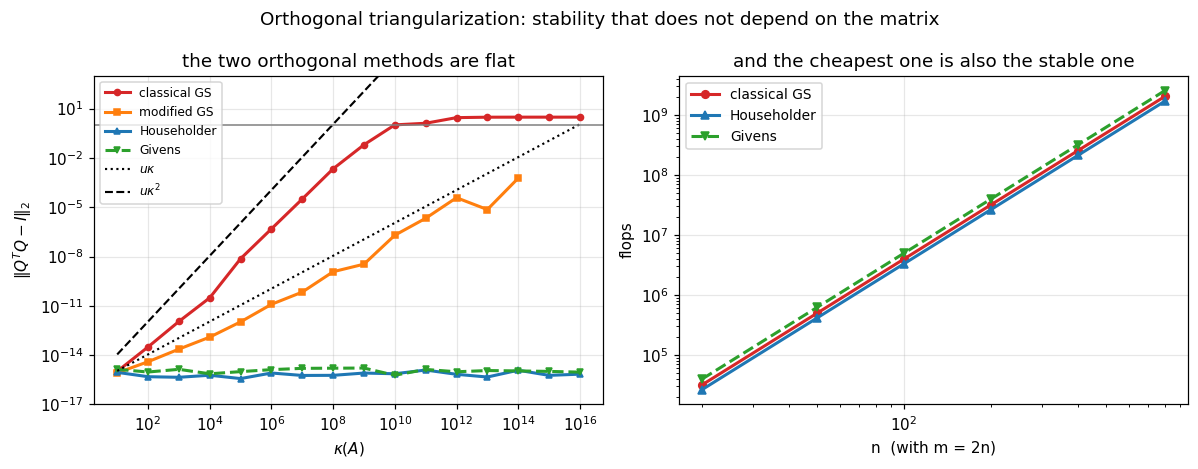

In [14]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))

sweep = np.arange(1, 17)
for name, factorize, style in [("classical GS", qr.gram_schmidt_classical, "C3o-"),
                               ("modified GS", qr.gram_schmidt_modified, "C1s-"),
                               ("Householder", qr.householder_qr, "C0^-"),
                               ("Givens", qr.givens_qr, "C2v--")]:
    xs, losses = [], []
    for exponent in sweep:
        A_p = ls.graded_design(40, 8, 10.0 ** float(exponent), np.random.default_rng(7))
        try:
            losses.append(max(qr.orthogonality_error(factorize(A_p)[0]), 1e-17))
            xs.append(10.0 ** float(exponent))
        except np.linalg.LinAlgError:
            pass                                  # the routine refused; nothing to plot
    axL.loglog(xs, losses, style, lw=2, ms=4, label=name)

u = np.finfo(float).eps / 2
axL.loglog(10.0 ** sweep, u * 10.0 ** sweep, "k:", lw=1.4, label=r"$u\kappa$")
axL.loglog(10.0 ** sweep, u * 10.0 ** (2.0 * sweep), "k--", lw=1.4, label=r"$u\kappa^2$")
axL.axhline(1.0, color="0.5", lw=1.0)
axL.set_ylim(1e-17, 1e3)
axL.set_xlabel(r"$\kappa(A)$")
axL.set_ylabel(r"$\|Q^TQ - I\|_2$")
axL.set_title("the two orthogonal methods are flat")
axL.legend(fontsize=8, loc="upper left")

sizes = np.array([20, 50, 100, 200, 400, 800])
for name, key, style in [("classical GS", "cgs", "C3o-"),
                         ("Householder", "householder", "C0^-"),
                         ("Givens", "givens", "C2v--")]:
    axR.loglog(sizes, [qr.flops_qr(2 * s, s, key) for s in sizes], style, lw=2, ms=5,
               label=name)
axR.set_xlabel("n  (with m = 2n)")
axR.set_ylabel("flops")
axR.set_title("and the cheapest one is also the stable one")
axR.legend(fontsize=9)

fig.suptitle("Orthogonal triangularization: stability that does not depend on the matrix",
             fontsize=12)
fig.tight_layout()
plt.show()

---

## 10. Exercises

**Level 1, conceptual**

1.1 Why is $P^{-1} = P$ for a Householder reflector, and what does that save?

1.2 Both signs give a valid reflector. Why does one of them destroy the factorization?

1.3 A colleague says Householder QR must be slower than Gram-Schmidt because it is more stable.
What is wrong with the reasoning?

**Level 2, mathematical**

2.1 Prove that $P = I - 2\mathbf{v}\mathbf{v}^T/\mathbf{v}^T\mathbf{v}$ is symmetric,
orthogonal and involutive, and that its eigenvalues are $-1$ once and $+1$ with multiplicity
$m-1$.

2.2 Show that $\mathbf{v} = \mathbf{x} - \alpha\mathbf{e}_1$ with $|\alpha| = \|\mathbf{x}\|$
gives $P\mathbf{x} = \alpha\mathbf{e}_1$, for either sign, and derive the relative error in
$v_1$ for the bad choice as a function of $x_1/\|\mathbf{x}\|$.

2.3 Count the flops in Householder QR exactly, including the reflector construction, and
confirm $2mn^2 - 2n^3/3$. Then count the extra cost of forming $Q$ explicitly.

2.4 Prove Theorem 31.2's orthogonality half: that a product of $n$ computed reflectors is
orthogonal to $O(nu)$, independently of what it was applied to.

2.5 Show that a Givens QR of an upper Hessenberg matrix needs exactly $n-1$ rotations, and that
the result is upper triangular with bandwidth 2 more than the original.

**Level 3, computational**

3.1 Implement **blocked Householder QR** using the WY representation, which applies several
reflectors as one matrix product. Measure the speedup against the unblocked version and explain
it with lesson 08's roofline.

3.2 Implement **Householder QR for a complex matrix**, where the sign choice becomes a phase
choice. Verify unitarity and say what replaces $\operatorname{sign}(x_1)$.

3.3 Implement **QR updating**: given $A = QR$ and a new row appended to $A$, produce the new
factorization in $O(mn)$ using Givens rotations rather than refactoring in $O(mn^2)$. Measure
the saving.

**Level 4, experimental**

4.1 Measure the orthogonality of Householder QR against $\kappa$ up to $10^{18}$ and confirm it
never degrades. Then do the same for the **product** $QR$ and for $Q$ and $R$ individually,
against a higher precision reference.

4.2 Time all four factorizations against $n$ for square matrices and against $m$ for fixed $n$.
Compare with the flop counts and identify where BLAS level 3 changes the ranking.

4.3 Take a banded matrix of bandwidth $p$ and measure the Givens rotation count and the run time
against $p$, from tridiagonal to dense. Find the $p$ at which Householder becomes cheaper.

**Level 5, advanced**

5.1 **Why the product is accurate when the factors are not.** State the backward stability
result precisely, and design an experiment separating three quantities: the error in $Q$, the
error in $R$, and the error in $QR$. Explain why only the third one is bounded independently of
$\kappa$.

5.2 **Reflections against rotations, counted properly.** A reflection clears a column in one
step and a rotation clears one entry. Work out the crossover in flops, in memory traffic, and
in parallel depth, and explain why the three give different answers.

5.3 **The CS decomposition and QR of a product.** Given QR factorizations of $A$ and $B$, can
you obtain one for $[A\ B]$ or for $AB$ cheaply? Investigate, and relate what you find to why
QR is not used as a general-purpose matrix representation the way LU is.

## 11. Key takeaways

- **A Householder reflector is orthogonal, symmetric and its own inverse**, so nothing in this
  lesson inverts anything. Verified to $10^{-16}$ on all three properties.
- **The sign choice is not a detail.** Measured: with the wrong sign at $x_1 = 10^{8}$ the
  leading entry of the reflector cancels to **exactly zero**, and the reflection then negates
  the tail instead of removing it, leaving it **exactly as large as before** with no error
  reported. With the right sign the entries below the diagonal are **exactly zero** at every
  input tested.
- **Householder QR is orthogonal at every condition number.** Measured flat at $10^{-15}$ from
  $\kappa = 10$ to $\kappa = 10^{15}$, where classical Gram-Schmidt has lost everything.
  Orthogonality is a property of the operations, so it cannot degrade with the matrix.
- **$R$ is exactly zero below the diagonal**, because those entries are assigned rather than
  computed. Gram-Schmidt cannot make that promise.
- **Never form the reflector.** Applying it as a rank-one update turns $O(m^2n)$ into
  $O(mn)$. Measured, the update is **slower** at $m = 20$, where BLAS overhead dominates, and
  3 to 4 times faster from $m = 200$ up. The speedup **saturates** well below the flop ratio of
  $m$, because both operations are memory bound at that size, which is lesson 08's roofline
  again. The storage saving is not a trade at any size: $m$ entries against $m^2$.
- **Never form $Q$ either.** At $m = 10^{5}$, $n = 10$ the dense $Q$ would be $10^{10}$
  entries, 80 GB, for data occupying 8 MB. The reflectors occupy 8 MB, the same as the data,
  and satisfy
  $Q^TQ\mathbf{y} = \mathbf{y}$ to $10^{-15}$, an identity checkable at any size because it
  needs no reference.
- **The computed factors drift with $\kappa$ and their product does not.** That is what backward
  stability means, and it is enough because nothing downstream uses $Q$ and $R$ separately.
- **Householder is cheaper than Gram-Schmidt**, $4n^3/3$ against $2n^3$ at $m = n$, which
  surprises people who expect stability to cost something. What costs extra is forming $Q$.
- **Givens costs 50 percent more on a dense matrix and far less on a structured one.** Measured:
  a Hessenberg matrix needs $n-1$ rotations against a dense matrix's $n^2/2$, a ratio of $2/n$,
  so at $n = 400$ it is 200 times cheaper.
- **Householder and Givens give the same answer to a factor of two** at every condition number,
  because they are the same idea built from different orthogonal pieces.

## Where this goes next

**Lesson 32** puts the whole comparison on a proper footing: not one condition number but four,
the role of the angle between $\mathbf{b}$ and $\operatorname{range}(A)$, the pseudoinverse, and
the SVD as the method that survives where even QR does not.

**Lesson 33** drops the full column rank assumption, which is where QR needs **column pivoting**
and where "numerical rank" has to be defined rather than assumed.

**Lesson 39** applies the same reflectors to a completely different problem: reducing a matrix
to Hessenberg form so that the QR **algorithm** for eigenvalues becomes affordable. The
factorization and the algorithm share a name and are not the same thing.

Solutions are in [`solutions/part05_least_squares_and_qr.md`](../solutions/part05_least_squares_and_qr.md).